# Vessel Trajectory Prediction Using Deep Learning on AIS Data
**CS 1090B Milestone 4; Group 24**  
**Members:** Yuyang Chen, Tim Guo, Lillian Yang, Grace Yang

---

## Table of Contents
1. [Dependencies](#1-dependencies)
2. [Setup](#2-setup)
   - [2.1 Imports](#21-imports)
   - [2.2 Configuration](#22-configuration)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [DataLoaders](#5-dataloaders)
6. [Model Definitions](#6-model-definitions)
   - [6.1 Constant Velocity Baseline](#61-constant-velocity-model-baseline)
   - [6.2 MLP](#62-mlp)
   - [6.3 LSTM](#63-lstm)
   - [6.4 Transformer](#64-transformer-encoder--query-decoder)
7. [Load / Train Models](#7-load--train-models)
   - [7.1 CVM](#71-constant-velocity-model-baseline)
   - [7.2 MLP](#72-mlp)
   - [7.3 LSTM](#73-LSTM)
   - [7.4 Transformer](#74-transformer)
8. [Evaluation](#8-evaluation)
9. [Results & Comparison](#9-results--comparison)
   - [9.1 Overall](#overall-summary-table)
   - [9.2 SOG-Stratified](#sog-stratified-evaluation)


## 1. Dependencies

Install all required packages before running the rest of the notebook. 

In [1]:
%pip install -q numpy pandas torch matplotlib pyarrow
import importlib
for pkg in ['numpy','pandas','torch','matplotlib','pyarrow']:
    mod = importlib.import_module(pkg)
    print(f'  {pkg:<12} {mod.__version__}')
print('All dependencies satisfied.')


Note: you may need to restart the kernel to use updated packages.
  numpy        1.26.3
  pandas       2.2.0
  torch        2.10.0
  matplotlib   3.8.2
  pyarrow      23.0.1
All dependencies satisfied.


## 2. Setup


### 2.1 Imports


In [2]:
import os
import math
import time
import json
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import torch
import torch.nn as nn

from pathlib import Path
from contextlib import nullcontext

warnings.filterwarnings('ignore')
print('Imports complete.')


Imports complete.


### 2.2 Configuration

Label folder paths. 

| Variable | Purpose |
|---|---|
| `PROJECT_DIR` | Root of the `DATASET_BALANCED` folder on disk |
| `device` | `cuda` if a GPU is available, else `cpu` |
| `SEED` | Global random seed for reproducibility |



In [3]:
PROJECT_DIR = Path('/shared/home/liy159/DATASET_BALANCED')
os.chdir(PROJECT_DIR)

SEED = 109

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device           : {device}')
if device.type == 'cuda':
    print(f'GPU              : {torch.cuda.get_device_name(0)}')
print(f'Working directory: {os.getcwd()}')


Device           : cuda
GPU              : NVIDIA L4
Working directory: /shared/home/liy159/DATASET_BALANCED


## 3. Preprocessing Pipeline

The raw AIS data (NOAA MarineCadastre, May-Aug 2024) was preprocessed once and saved to Parquet. Running the full pipeline from raw CSVs takes approximately 45 minutes. The cell below checks for processed files first and skips if they already exist. Raw CSVs can be obtained from [NOAA MarineCadastre](https://marinecadastre.gov/ais/) and placed in `PROJECT_DIR/raw/`.

### Pipeline Overview

| Step | Description |
|---|---|
| **1. Filter** | Bounding box 14-52 N, 114-132 W (US West Coast); drop rows missing MMSI, timestamp, lat, or lon |
| **2. Trip segmentation** | Split tracks wherever consecutive pings are >30 min apart; drop trips with <10 points -> 331k trips, 19k vessels |
| **3. Resample** | Uniform 3-minute grid per trip via `pandas.resample` |
| **4. Interpolate** | Linear for lat/lon/SOG; circular (via sin/cos) for COG and heading |
| **5. Train rebalance** | Trips with mean SOG < 0.5 kt dropped from train only; val/test left intact |
| **6. Feature stats** | Mean/std/min/max computed on training rows only to prevent data leakage |
| **7. Splits** | 70/15/15 vessel-level split (seed 42) -- no vessel spans train and test |


In [4]:
# preprocessing pieces
PROC_PARQUET = PROJECT_DIR / 'processed' / 'ais_trajectories_West_Coast_3min.parquet'
SPLITS_FILE  = PROJECT_DIR / 'processed' / 'splits_West_Coast_3min.parquet'
STATS_FILE   = PROJECT_DIR / 'processed' / 'feature_stats_West_Coast_3min.csv'

if PROC_PARQUET.exists() and SPLITS_FILE.exists() and STATS_FILE.exists():
    print('Processed files already exist -- skipping preprocessing.')
    for f in [PROC_PARQUET, SPLITS_FILE, STATS_FILE]:
        print(f'  {f.name}')
else:
    print('Running preprocessing pipeline ...')
    RAW_DIR = PROJECT_DIR / 'raw'
    TIMESTEP_MIN = 3
    LAT_MIN, LAT_MAX = 14.0, 52.0
    LON_MIN, LON_MAX = -132.0, -114.0
    GAP_THRESHOLD = pd.Timedelta(minutes=30)
    MIN_TRIP_PTS = 10
    MIN_TRAIN_SOG = 0.5

    # load & filter data
    COLS = ['MMSI','BaseDateTime','LAT','LON','SOG','COG','Heading',
            'VesselType','Status','Length','Width','Draft','VesselName',
            'IMO','CallSign','Cargo','TransceiverClass']
    frames = []
    for f in sorted(RAW_DIR.glob('AIS_*.csv')):
        df = pd.read_csv(f, usecols=[c for c in COLS if c in pd.read_csv(f, nrows=0).columns], low_memory=False)
        df = df.rename(columns={'BaseDateTime':'base_date_time','LAT':'latitude','LON':'longitude',
                                 'SOG':'sog','COG':'cog','Heading':'heading','VesselType':'vessel_type',
                                 'Status':'status','Length':'length','Width':'width','Draft':'draft',
                                 'VesselName':'vessel_name','IMO':'imo','CallSign':'call_sign',
                                 'Cargo':'cargo','TransceiverClass':'transceiver','MMSI':'mmsi'})
        mask = ((df['latitude'] >= LAT_MIN) & (df['latitude'] <= LAT_MAX) &
                (df['longitude'] >= LON_MIN) & (df['longitude'] <= LON_MAX))
        frames.append(df[mask])
    df = pd.concat(frames, ignore_index=True)
    df['base_date_time'] = pd.to_datetime(df['base_date_time'], errors='coerce')
    df = df.dropna(subset=['mmsi','base_date_time','latitude','longitude'])
    df = df.sort_values(['mmsi','base_date_time']).reset_index(drop=True)
    print(f'Step 1: {len(df):,} rows, {df["mmsi"].nunique():,} vessels')

    # segment trips
    def assign_trip_ids(group):
        times = group['base_date_time'].values
        diffs = np.diff(times).astype('timedelta64[s]').astype(float)
        trip_id = np.zeros(len(group), dtype=int)
        tid = 0
        for i, d in enumerate(diffs):
            if d > GAP_THRESHOLD.total_seconds(): tid += 1
            trip_id[i+1] = tid
        group = group.copy()
        group['trip_seg'] = trip_id
        group['trip_id'] = group['mmsi'].astype(str) + '_' + trip_id.astype(str)
        return group
    df = df.groupby('mmsi', group_keys=False).apply(assign_trip_ids)
    counts = df.groupby('trip_id').size()
    df = df[df['trip_id'].isin(counts[counts >= MIN_TRIP_PTS].index)].reset_index(drop=True)
    print(f'Step 2: {df["trip_id"].nunique():,} trips')

    # resample + circular interpolation
    def interp_circular(s):
        r = np.deg2rad(s.values.astype(float))
        s_ = pd.Series(np.sin(r), index=s.index).interpolate('time')
        c_ = pd.Series(np.cos(r), index=s.index).interpolate('time')
        return pd.Series(np.rad2deg(np.arctan2(s_, c_)) % 360, index=s.index)
    def resample_trip(g):
        g = g.set_index('base_date_time').sort_index()
        g = g[~g.index.duplicated(keep='first')]
        r = g.resample(f'{TIMESTEP_MIN}min').asfreq()
        r[['latitude','longitude','sog']] = r[['latitude','longitude','sog']].interpolate('time')
        for col in ['cog','heading']:
            if col in r.columns: r[col] = interp_circular(r[col])
        r['mmsi'] = g['mmsi'].iloc[0]
        r['trip_id'] = g['trip_id'].iloc[0]
        r['trip_seg'] = g['trip_seg'].iloc[0]
        return r.dropna(subset=['latitude','longitude','sog'])
    df = df.groupby('trip_id', group_keys=False).apply(resample_trip).reset_index().rename(columns={'index':'base_date_time'})
    print(f'Steps 3-4: {len(df):,} rows after resampling')

    # rebalance, feature stats, vessel-level splits
    vessels = df['mmsi'].unique(); np.random.seed(SEED); np.random.shuffle(vessels)
    n = len(vessels)
    splits_df = pd.DataFrame({'mmsi': vessels,
        'split': (['train']*int(0.70*n) + ['val']*int(0.15*n) + ['test']*(n-int(0.70*n)-int(0.15*n)))})
    df = df.merge(splits_df, on='mmsi', how='left')
    trip_sog = df[df['split']=='train'].groupby('trip_id')['sog'].mean()
    slow_trips = trip_sog[trip_sog < MIN_TRAIN_SOG].index
    df = df[~((df['split']=='train') & (df['trip_id'].isin(slow_trips)))].reset_index(drop=True)
    FEAT_COLS = ['latitude','longitude','sog','cog','heading','length','width','draft']
    stats = df[df['split']=='train'][[c for c in FEAT_COLS if c in df.columns]].agg(['mean','std','min','max'])
    STATS_FILE.parent.mkdir(exist_ok=True)
    stats.to_csv(STATS_FILE)
    df.drop(columns=['split']).to_parquet(PROC_PARQUET, index=False)
    splits_df.to_parquet(SPLITS_FILE, index=False)
    print(f'Saved processed files to {PROC_PARQUET.parent}')


Processed files already exist -- skipping preprocessing.
  ais_trajectories_West_Coast_3min.parquet
  splits_West_Coast_3min.parquet
  feature_stats_West_Coast_3min.csv


## 4. Exploratory Data Analysis

Before modelling we examine three key questions:

1. **Speed distribution**: what fraction of the fleet is mostly stationary (mean SOG < 0.5 kt)?
2. **Trip duration**: are most trips short bursts or multi-hour transits?
3. **Geographic coverage**: where are the activity hotspots?

All plots are generated from the preprocessed Parquet file. Figures are saved as `eda_trip_stats.png` and `eda_density.png` for inclusion in the final report.


In [5]:
traj_path = PROJECT_DIR / 'processed' / 'ais_trajectories_West_Coast_3min.parquet'
df_raw = pd.read_parquet(traj_path, columns=['trip_id','mmsi','latitude','longitude','sog','base_date_time'])
print(f'Rows       : {len(df_raw):,}')
print(f'Vessels    : {df_raw["mmsi"].nunique():,}')
print(f'Trips      : {df_raw["trip_id"].nunique():,}')
print(f'Date range : {df_raw["base_date_time"].min()} -> {df_raw["base_date_time"].max()}')


Rows       : 128,468,095
Vessels    : 19,004
Trips      : 331,088
Date range : 2024-05-01 00:00:00 -> 2024-08-31 23:57:00


In [6]:
# trip-level summary statistics
trip_stats = df_raw.groupby('trip_id').agg(n_pts=('latitude','count'), mean_sog=('sog','mean')).reset_index()
trip_stats['duration_min'] = trip_stats['n_pts'] * 3
trip_stats['is_stationary'] = trip_stats['mean_sog'] < 0.5
print(f'Total trips       : {len(trip_stats):,}')
print(f'Mostly stationary : {trip_stats["is_stationary"].mean()*100:.1f}%  (mean SOG < 0.5 kt)')
print(trip_stats[['n_pts','mean_sog','duration_min']].describe().round(2))


Total trips       : 331,088
Mostly stationary : 21.9%  (mean SOG < 0.5 kt)
           n_pts   mean_sog  duration_min
count  331088.00  330968.00     331088.00
mean      388.02       4.81       1164.05
std      1218.88       4.93       3656.65
min        10.00       0.00         30.00
25%        41.00       0.70        123.00
50%        85.00       3.64        255.00
75%       211.00       6.95        633.00
max     24869.00      48.50      74607.00


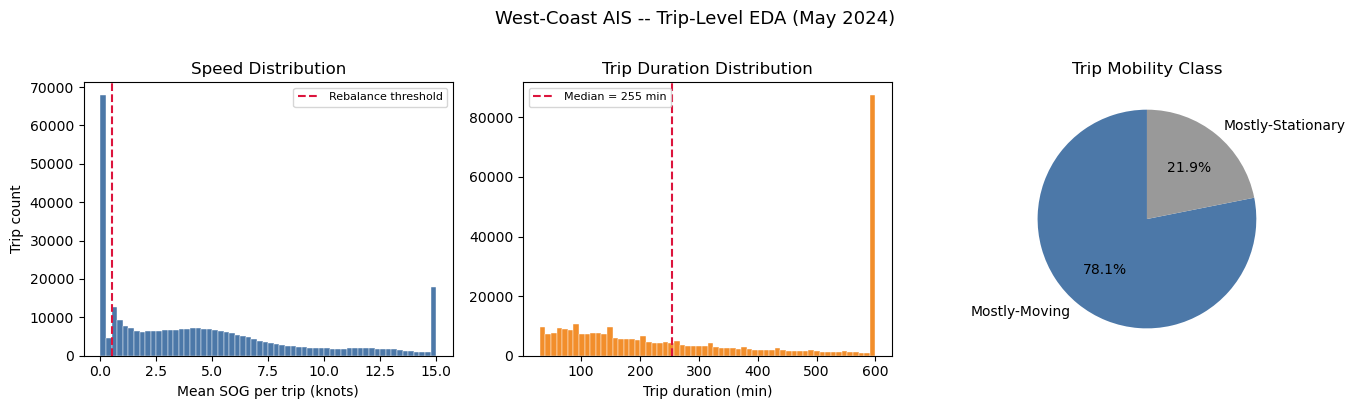

Saved: eda_trip_stats.png


In [7]:
# speed distribution, trip duration, mobility class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(trip_stats['mean_sog'].clip(upper=15), bins=60, color='#4C78A8', edgecolor='white', lw=0.3)
axes[0].axvline(0.5, color='crimson', ls='--', lw=1.5, label='Rebalance threshold')
axes[0].set_xlabel('Mean SOG per trip (knots)'); axes[0].set_ylabel('Trip count')
axes[0].set_title('Speed Distribution'); axes[0].legend(fontsize=8)

axes[1].hist(trip_stats['duration_min'].clip(upper=600), bins=60, color='#F28E2B', edgecolor='white', lw=0.3)
axes[1].axvline(trip_stats['duration_min'].median(), color='crimson', ls='--', lw=1.5,
                label=f'Median = {trip_stats["duration_min"].median():.0f} min')
axes[1].set_xlabel('Trip duration (min)'); axes[1].set_title('Trip Duration Distribution')
axes[1].legend(fontsize=8)

counts = trip_stats['is_stationary'].value_counts()
axes[2].pie(counts, labels=['Mostly-Moving','Mostly-Stationary'],
            autopct='%1.1f%%', colors=['#4C78A8','#999999'], startangle=90)
axes[2].set_title('Trip Mobility Class')

plt.suptitle('West-Coast AIS -- Trip-Level EDA (May 2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eda_trip_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_trip_stats.png')


**EDA Takeaways (Figure 1):**

- About 21.9% of trips are mostly stationary (mean SOG < 0.5 kt). This means anchored or docked vessels that contribute little predictive signal. Dropping them from training prevents the model from learning a degenerate 'stay still' solution.
- The median trip duration is 255 minutes (~4.25 h), confirming that a 60-minute forecast horizon is meaningful and achievable for the majority of vessels.
- Speed is right-skewed: most vessels travel at 3-8 knots with a long tail to 48 knots (ferries, pleasure craft).


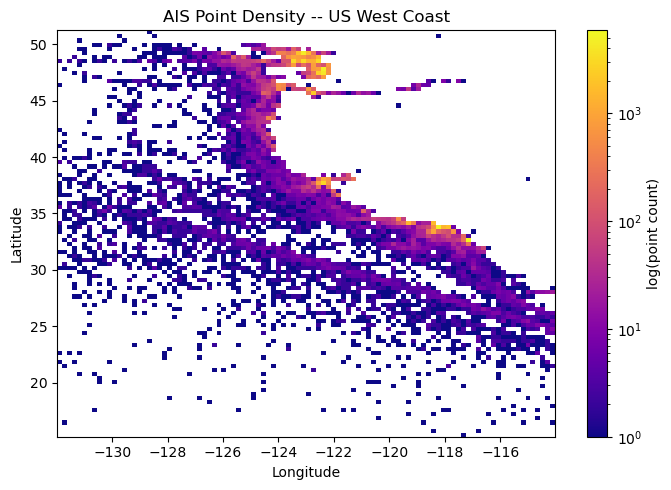

Saved: eda_density.png


In [8]:
# geographic density map
sample = df_raw.sample(min(100_000, len(df_raw)), random_state=SEED)
fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(sample['longitude'], sample['latitude'], bins=100,
              cmap='plasma', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(h[3], ax=ax, label='log(point count)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('AIS Point Density -- US West Coast')
plt.tight_layout()
plt.savefig('eda_density.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_density.png')

# free memory before model training
del df_raw, sample, trip_stats


**EDA Takeaways (Figure 2):**

Three dominant hotspots correspond to the busiest US West Coast ports: Puget Sound/Seattle, San Francisco Bay, and Los Angeles/Long Beach. The California Current shipping lane is visible as a dense diagonal band along the coast. Sparse coverage in the open Pacific reflects outlier vessel types (research, long-range fishing).


## 5. DataLoaders

All three models share a single `dataloader.py` helper that handles windowing, feature encoding, normalisation, and vessel-level splitting, ensuring identical inputs and no data leakage.

### Windowing Strategy

Each trip is carved into overlapping windows with a stride of 5 steps (15 min):

```
|<-- 20 steps = 60 min (input) -->|<-- 20 steps = 3-60 min (target) -->|
```

Windows are assigned at vessel level: all windows from a given vessel belong to exactly one split, preventing any vessel from spanning the train/val/test boundary.

### Feature Encoding

| Feature | Raw | Encoded |
|---|---|---|
| Latitude | degrees | delta-km from last input step (relative) |
| Longitude | degrees | delta-km from last input step (relative) |
| SOG | knots | z-score normalised |
| COG | degrees | cos + sin (2 dims) |
| Heading | degrees | cos + sin (2 dims) |

Total input dimensionality: 7. Target: (delta-lat_km, delta-lon_km), a 2-D displacement vector enabling straightforward evaluation in km without inverse coordinate transformations.


In [9]:
import importlib, dataloader
importlib.reload(dataloader)
from dataloader import get_dataloaders

FEATURES   = ['lat', 'lon', 'sog', 'cog', 'heading']
INPUT_LEN  = 20    # 60 min of history
TARGET_LEN = 20    # 60 min of forecast
STRIDE     = 5     # slide by 15 min between windows
BATCH_SIZE = 1024

train_loader, val_loader, test_loader = get_dataloaders(
    features=FEATURES, input_len=INPUT_LEN, target_len=TARGET_LEN,
    stride=STRIDE, batch_size=BATCH_SIZE, num_workers=2,
    position_encoding='relative',
)

train_ds     = train_loader.dataset
N_FEATURES   = train_ds.n_features
OUTPUT_NAMES = train_ds.output_names
LAT_IDX      = OUTPUT_NAMES.index('lat_rel_km')
LON_IDX      = OUTPUT_NAMES.index('lon_rel_km')

# Indices used by the new LSTM (predicts all 7 features, scores only lat/lon)
TARGET_IDX  = [LAT_IDX, LON_IDX]
N_TARGETS   = len(TARGET_IDX)

# Locate angular (cos, sin) feature pairs for unit-circle projection inside LSTM
ANGULAR_PAIRS = []
for i, name in enumerate(OUTPUT_NAMES):
    if name.endswith('_cos'):
        sin_name = name[:-4] + '_sin'
        if sin_name in OUTPUT_NAMES:
            ANGULAR_PAIRS.append((i, OUTPUT_NAMES.index(sin_name)))

print(f'Input features ({N_FEATURES}): {OUTPUT_NAMES}')
print(f'Target indices (lat, lon)   : {TARGET_IDX}')
print(f'Angular pairs  (cos, sin)   : {ANGULAR_PAIRS}')
print(f'Train  : {len(train_ds):>12,} windows')
print(f'Val    : {len(val_loader.dataset):>12,} windows')
print(f'Test   : {len(test_loader.dataset):>12,} windows')


[train] 57,614,788 rows, 180,280 trips, 10,306,417 windows | features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7) | position_encoding=relative
[val] 34,915,380 rows, 76,659 trips, 6,457,737 windows | features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7) | position_encoding=relative
[test] 35,937,927 rows, 74,149 trips, 6,678,696 windows | features=['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin'] (n=7) | position_encoding=relative
Input features (7): ['lat_rel_km', 'lon_rel_km', 'sog_norm', 'cog_cos', 'cog_sin', 'heading_cos', 'heading_sin']
Target indices (lat, lon)   : [0, 1]
Angular pairs  (cos, sin)   : [(3, 4), (5, 6)]
Train  :   10,306,417 windows
Val    :    6,457,737 windows
Test   :    6,678,696 windows


## 6. Model Definitions

We implement three model architectures ranging from a simple feedforward baseline to a full Transformer with a learned query decoder. All models share the same input/output:

- **Input:** `(B, 20, 7)` -- batch x 20 time steps x 7 kinematic features
- **Output:** `(B, 20, 2)` -- batch x 20 forecast horizons x (delta-lat_km, delta-lon_km)

This common interface allows transparent model substitution in the evaluation loop (Section 8). We just defined classes here, the checkpoint loading and training are in Section 7.


### 6.1 Constant Velocity Model Baseline

The constant velocity model will serve as our baseline for our following deep-learning models. It directly uses the velocity field of the data (SOG and COG features) to calculate a velocity which is then multiplied by the time we wish to predict and added to our previous data point's coordinate. We use an euclidean distance error loss for training. 

This model serves as the baseline for the rest of our approaches (MLP as the most basic deep learning model, LSTM/Transformer as our deep learning time-series models). We aim to outperform these results. 


In [10]:
def calculate_sog_cog_mde(dataloader):
    # determine indices based on DEFAULT_FEATURES = ["lat", "lon", "sog", "cog", "heading"]
    LAT_IDX, LON_IDX = 0, 1
    SOG_IDX = 2
    COG_COS_IDX, COG_SIN_IDX = 3, 4
    
    ds = dataloader.dataset
    while isinstance(ds, torch.utils.data.Subset):
        ds = ds.dataset
        
    sog_mu = ds.mean['sog']
    sog_std = ds.std['sog']
    
    # constants for unit conversion
    KM_PER_KNOT = 1.852
    HOURS_PER_STEP = TIMESTEP_MIN / 60.0
    
    total_errors = None
    num_samples = 0

    with torch.no_grad():
        for x, y in dataloader:
            batch_size = x.size(0)
            target_len = y.size(1)
            
            # extract values from the last input timestep (index -1)
            sog_norm = x[:, -1, SOG_IDX]
            cog_cos = x[:, -1, COG_COS_IDX]
            cog_sin = x[:, -1, COG_SIN_IDX]
            
            # denormalize SOG (z-score -> knots) and convert to km/step
            sog_knots = (sog_norm * sog_std) + sog_mu
            # Ensure SOG is non-negative (ReLU-like guard for noise)
            sog_knots = torch.clamp(sog_knots, min=0.0)
            
            v_mag_step = sog_knots * KM_PER_KNOT * HOURS_PER_STEP
            
            # create the velocity vector [delta_lat_km, delta_lon_km]
            v_dir = torch.stack([cog_cos, cog_sin], dim=-1)
            v_step = v_mag_step.unsqueeze(-1) * v_dir
            
            # project future positions
            k_steps = torch.arange(1, target_len + 1, device=x.device).view(1, -1, 1)
            
            # predictions: last input is origin (0,0), so pred = k * v_step
            preds = k_steps * v_step.unsqueeze(1) # (batch, 20, 2)
            targets = y[:, :, [LAT_IDX, LON_IDX]]
            dist_error = torch.sqrt(torch.sum((preds - targets)**2, dim=-1))
            
            if total_errors is None:
                total_errors = dist_error.sum(dim=0)
            else:
                total_errors += dist_error.sum(dim=0)
            num_samples += batch_size

    mde = (total_errors / num_samples).cpu().numpy()
    return mde

### 6.2 MLP

The Multi-Layer Perceptron flattens the entire input window into a single vector and passes it through two hidden layers before predicting all 20 future displacement vectors at once.

Architecture: `Flatten -> Linear(1400->256) -> ReLU -> Linear(256->128) -> ReLU -> Linear(128->40) -> reshape(B,20,2)`

The MLP treats the 60-minute history as a bag of features with no explicit notion of time ordering. Despite this simplicity, it provides a strong baseline because sliding-window AIS data is locally smooth and well-structured. We have approximately 74 k parameters.


In [11]:
class TrajectoryMLP(nn.Module):
    '''.
    Input  : (B, input_len, n_features)
    Output : (B, target_len, 2) displacement [delta_lat_km, delta_lon_km]
    '''
    def __init__(self, input_len, n_features, target_len, n_targets=2, hidden1=256, hidden2=128):
        super().__init__()
        self.target_len = target_len
        self.n_targets  = n_targets
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_len * n_features, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),                nn.ReLU(),
            nn.Linear(hidden2, target_len * n_targets),
        )
    def forward(self, x):
        return self.net(x).view(-1, self.target_len, self.n_targets)

_n = sum(p.numel() for p in TrajectoryMLP(INPUT_LEN, N_FEATURES, TARGET_LEN).parameters())
print(f'TrajectoryMLP defined  ({_n:,} params)')


TrajectoryMLP defined  (74,152 params)


### 6.3 LSTM

The Long Short-Term Memory network explicitly models the sequential nature of vessel movement using a 2-layer LSTM encoder with an autoregressive decoder.
Design choices:

1. Predicts all 7 features (not just lat/lon). Speed/course outputs are supervised indirectly through their effect on future lat/lon predictions, preventing the model from freezing velocity at the last observed step during long rollouts.
2. Unit-circle projection on angular (cos, sin) pairs after each fc step, so predicted COG/heading inputs stay on the same manifold as training data through the entire autoregressive rollout.
3. Scheduled sampling: linear decay of teacher forcing ratio from tfr=1.0 to tfr=0.5 across post-warmup epochs. Pure teacher forcing at train + pure autoregressive at test = exposure bias; scheduled sampling trains the model on a mix of true and predicted inputs so it can recover from its own errors at inference.
4. LayerNorm + Dropout (p=0.2): applied after the LSTM output to reduce overfitting.

There are approximately 1.0 M parameters. Hidden size: 256. Layers: 2.


In [12]:
def haversine_km(pred, true, lat_idx=0, lon_idx=1, ref_lat_deg=37.0):
    """Haversine distance error in km from relative-km predictions.

    pred, true : (batch, target_len, >=2)  lat/lon channels in km
    Returns    : (batch, target_len)
    """
    import math as _math
    R       = 6371.0
    to_rad  = _math.pi / 180.0
    cos_ref = _math.cos(ref_lat_deg * to_rad)

    dlat_deg = (pred[:, :, lat_idx] - true[:, :, lat_idx]) / 111.320
    dlon_deg = (pred[:, :, lon_idx] - true[:, :, lon_idx]) / (111.320 * cos_ref)

    dlat = dlat_deg * to_rad
    dlon = dlon_deg * to_rad

    a = torch.sin(dlat / 2)**2 + cos_ref**2 * torch.sin(dlon / 2)**2
    return 2 * R * torch.asin(torch.clamp(torch.sqrt(a), 0, 1))

print('haversine_km helper defined.')


haversine_km helper defined.


In [13]:
class VesselLSTM(nn.Module):
    """LSTM forecaster
    Input  : x (B, input_len,  n_features)
             y (B, target_len, n_features)
    Output : (B, target_len, n_features)
    """
    def __init__(self, n_features, hidden_size, num_layers,
                 target_len, dropout=0.2,
                 target_idx=(0, 1), angular_pairs=()):
        super().__init__()
        self.target_len   = target_len
        self.n_features   = n_features
        self.register_buffer('target_idx',
                             torch.as_tensor(target_idx, dtype=torch.long))
        self.angular_pairs = list(angular_pairs)
        self.lstm       = nn.LSTM(n_features, hidden_size, num_layers,
                                  batch_first=True,
                                  dropout=dropout if num_layers > 1 else 0.0)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_size, n_features)

    def _project(self, h):
        """fc + unit-circle normalization on angular pairs (out-of-place)"""
        out = self.fc(self.dropout(self.layer_norm(h)))
        if not self.angular_pairs:
            return out
        channels = list(out.unbind(dim=-1))
        for cos_idx, sin_idx in self.angular_pairs:
            c, s = channels[cos_idx], channels[sin_idx]
            mag  = torch.sqrt(c * c + s * s + 1e-8)
            channels[cos_idx] = c / mag
            channels[sin_idx] = s / mag
        return torch.stack(channels, dim=-1)

    def forward(self, x, y=None, teacher_forcing_ratio=1.0):
        if y is None:
            return self._autoregressive(x)
        if teacher_forcing_ratio >= 1.0:           # parallel teacher forcing
            full   = torch.cat([x, y[:, :-1]], dim=1)
            out, _ = self.lstm(full)
            return self._project(out)[:, -self.target_len:, :]
        return self._scheduled_sampling(x, y, teacher_forcing_ratio)

    def _autoregressive(self, x):
        out, (h, c) = self.lstm(x)
        pred_t = self._project(out[:, -1:, :])
        preds  = [pred_t]
        for _ in range(self.target_len - 1):
            out, (h, c) = self.lstm(pred_t, (h, c))
            pred_t      = self._project(out)
            preds.append(pred_t)
        return torch.cat(preds, dim=1)

    def _scheduled_sampling(self, x, y, p_teacher):
        """Per-step Bernoulli mix of teacher / student inputs"""
        out, (h, c) = self.lstm(x)
        pred_t = self._project(out[:, -1:, :])
        preds  = [pred_t]
        B      = x.size(0)
        for t in range(1, self.target_len):
            teacher_in = y[:, t-1:t, :]
            student_in = pred_t.to(teacher_in.dtype)
            mask       = (torch.rand(B, 1, 1, device=x.device) < p_teacher
                         ).to(teacher_in.dtype)
            next_in    = mask * teacher_in + (1.0 - mask) * student_in
            out, (h, c) = self.lstm(next_in, (h, c))
            pred_t      = self._project(out)
            preds.append(pred_t)
        return torch.cat(preds, dim=1)


_n = sum(p.numel() for p in VesselLSTM(N_FEATURES, 256, 2, TARGET_LEN,
         target_idx=tuple(TARGET_IDX), angular_pairs=tuple(ANGULAR_PAIRS)).parameters())
print(f'VesselLSTM (v2) defined ({_n:,} params)')

VesselLSTM (v2) defined (800,007 params)


### 6.4 Transformer (Encoder + Query Decoder)

The Transformer follows an encoder-decoder design, adapted for sequential trajectory forecasting.

1. Encoder: 4 Pre-LN `TransformerEncoderLayer` blocks (d_model=64, 4 heads, FFN=256, GELU) encode the 20-step history into a rich contextual memory.
2. Sinusoidal positional encoding: added to both encoder inputs and decoder queries.
3. Learnable query decoder: 20 trainable query embeddings (one per forecast step) attend over encoder memory via 2 cross-attention layers. Each horizon directly attends to the most relevant part of history rather than propagating state autoregressively.
4. Output head: `LayerNorm -> Linear(64->2)` projects each query to a displacement.

We have approximately 340 k parameters. Trained for 30 epochs (AdamW + cosine annealing). Parallel decoding at inference makes it faster than the autoregressive LSTM at long horizons.


In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
    def forward(self, x):
        return x + self.pe[:x.size(1)].unsqueeze(0)


class VesselTransformer(nn.Module):
    '''
    Input  : (B, input_len, input_dim)
    Output : (B, target_len, 2)  -- displacement [delta_lat_km, delta_lon_km]
    '''
    def __init__(self, input_dim=7, target_len=20, target_dim=2,
                 d_model=64, nhead=4, num_encoder_layers=4,
                 num_decoder_layers=2, dim_feedforward=256, dropout=0.2):
        super().__init__()
        self.target_len = target_len
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)
        self.future_queries = nn.Parameter(torch.randn(target_len, d_model))
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_decoder_layers)
        self.out = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, target_dim))

    def forward(self, src):
        B   = src.size(0)
        mem = self.pos_encoder(self.input_proj(src))
        mem = self.encoder(mem)
        q   = self.pos_encoder(self.future_queries.unsqueeze(0).expand(B, -1, -1))
        return self.out(self.decoder(tgt=q, memory=mem))

_n = sum(p.numel() for p in VesselTransformer().parameters())
print(f'VesselTransformer defined ({_n:,} params)')

VesselTransformer defined (335,490 params)


## 7. Load / Train Models

1. Check for a saved checkpoint on disk.
2. **If found** -- load weights, report parameter count, set `eval()` mode.
3. **If not found** -- run the full training loop and save the best checkpoint.

| Model | Checkpoint path | Training time (L4 GPU) |
|---|---|---|
| Constant Velocity | `../mde_constant_velocity_SOGCOG.npy` | ~2 min |
| MLP | `../MLP/final_model.pt` | ~5 min (10 epochs) |
| LSTM | `DATASET_BALANCED/best_lstm.pt` | ~40 min (20 epochs) |
| Transformer | `DATASET_BALANCED/trained_models/vessel_transformer_20260510_053103.pt` | ~2 h (30 epochs) |


### 7.1 Constant Velocity Model Baseline

The constant velocity model baseline is was trained at `../mde_constant_velocity_SOGCOG.npy` during Milestone 3. We reconstruct the identical architecture and load the saved weights.

If the checkpoint is **missing**, the cell below trains the constant velocity model, then saves the best checkpoint.

| Setting | Value |
|---|---|
| Type | Rule-based (no training) |
| Velocity source | Last input SOG + COG |
| Unit conversion | SOG (knots) × 1.852 × (3/60) km/step |
| Horizon | Linear extrapolation × k steps |

In [15]:
TIMESTEP_MIN = 3
try:
    mde_sog_cog = np.load('trained_models/mde_constant_velocity_SOGCOG.npy')
    print(f'CVM loaded')
except:
    mde_sog_cog = calculate_sog_cog_mde(test_loader)
    np.save('trained_models/mde_constant_velocity_SOGCOG.npy', mde_sog_cog)

CVM loaded


### 7.2 MLP

The MLP checkpoint was produced during Milestone 3 at `../MLP/final_model.pt`. We reconstruct the identical architecture and load the saved weights.

If the checkpoint is **missing**, the cell below trains the MLP for 10 epochs with Adam (lr=1e-3) and MSE loss on (delta-lat_km, delta-lon_km), then saves the best checkpoint. 
| Setting | Value |
|---|---|
| Optimizer | Adam (lr = 1×10⁻³) |
| Loss | Horizon-weighted Huber (β=1.0, weights 1.0→2.0) |
| Scheduler | None |
| Grad clip | None |
| Epochs | 10 |
| Batch size | 1,024 |



In [16]:
MLP_CKPT = PROJECT_DIR.parent / 'MLP' / 'final_model.pt'

mlp_model = TrajectoryMLP(
    input_len=INPUT_LEN, n_features=N_FEATURES,
    target_len=TARGET_LEN, n_targets=2, hidden1=256, hidden2=128,
).to(device)

if MLP_CKPT.exists():
    # load pre-trained checkpoint
    mlp_model.load_state_dict(torch.load(MLP_CKPT, map_location=device))
    mlp_model.eval()
    n = sum(p.numel() for p in mlp_model.parameters())
    print(f'MLP loaded ({n:,} params) <- {MLP_CKPT}')

else:
    # train from scratch
    print(f'Checkpoint not found at {MLP_CKPT} -- training MLP for 10 epochs ...')
    MLP_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)
    criterion_m = nn.MSELoss()
    optimizer_m = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)
    best_val = float('inf')
    for epoch in range(1, 11):
        t0 = time.time()
        mlp_model.train()
        tr = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer_m.zero_grad()
            loss = criterion_m(mlp_model(x), y[:, :, :2])
            loss.backward(); optimizer_m.step()
            tr += loss.item() * x.size(0)
        tr /= len(train_ds)
        mlp_model.eval()
        va = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                va += criterion_m(mlp_model(x), y[:, :, :2]).item() * x.size(0)
        va /= len(val_loader.dataset)
        tag = ''
        if va < best_val:
            best_val = va; torch.save(mlp_model.state_dict(), MLP_CKPT); tag = ' [saved]'
        print(f'Epoch {epoch:02d}/10  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s){tag}')
    mlp_model.load_state_dict(torch.load(MLP_CKPT, map_location=device))
    mlp_model.eval()
    print(f'MLP training complete.  Best val loss: {best_val:.4f}')


MLP loaded (74,152 params) <- /shared/home/liy159/MLP/final_model.pt


### 7.3 LSTM (v2 — scheduled sampling + angular projection)

The LSTM checkpoint lives at `trained_models/best_lstm.pt`. If the checkpoint is **missing**, the cell trains from scratch:

| Setting | Value |
|---|---|
| Optimizer | Adam (lr = 5×10⁻⁴) |
| Loss | Horizon-weighted Huber (β=1.0, weights 1.0→2.0) |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=2) |
| Grad clip | 1.0 |
| Epochs | 20 (early stop patience=7) |
| Warmup | 2 epochs full teacher forcing, then linear tfr decay to 0.5 |


In [17]:
# Horizon-weighted Huber loss 
horizon_weight = torch.linspace(1.0, 2.0, TARGET_LEN, device=device).view(1, TARGET_LEN, 1)
huber_fn       = nn.SmoothL1Loss(reduction='none', beta=1.0)

def weighted_huber(y_pred, y_true):
    '''y_pred, y_true: (B, T, 2) in km'''
    return (huber_fn(y_pred, y_true) * horizon_weight).mean()

# paths
LSTM_CKPT = PROJECT_DIR / 'trained_models' / 'best_lstm.pt'
LSTM_CSV  = PROJECT_DIR / 'trained_models' / 'haversine_per_horizon.csv'

# instantiate model
lstm_model = VesselLSTM(
    n_features=N_FEATURES, hidden_size=256, num_layers=2,
    target_len=TARGET_LEN, dropout=0.2,
    target_idx=tuple(TARGET_IDX),
    angular_pairs=tuple(ANGULAR_PAIRS),
).to(device)

if LSTM_CKPT.exists():
    lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=device))
    lstm_model.eval()
    n = sum(p.numel() for p in lstm_model.parameters())
    print(f'LSTM v2 loaded ({n:,} params) <- {LSTM_CKPT}')

else:
    print('No LSTM checkpoint -- training 20 epochs with scheduled sampling ...')
    LSTM_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)

    NUM_EPOCHS     = 20
    WARMUP_EPOCHS  = 2
    MIN_TF_RATIO   = 0.5
    PATIENCE_STOP  = 7

    def get_tfr(epoch):
        if epoch <= WARMUP_EPOCHS: return 1.0
        progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
        return max(MIN_TF_RATIO, 1.0 - progress * (1.0 - MIN_TF_RATIO))

    optimizer_l = torch.optim.Adam(lstm_model.parameters(), lr=5e-4)
    scheduler_l = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_l, mode='min', factor=0.5, patience=2)
    best_val, epochs_no_improve = float('inf'), 0

    for epoch in range(1, NUM_EPOCHS + 1):
        t0     = time.time()
        tf     = get_tfr(epoch)
        lstm_model.train()
        tr, n_tr = 0.0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer_l.zero_grad()
            pred = lstm_model(x, y=y, teacher_forcing_ratio=tf)
            loss = weighted_huber(pred[..., TARGET_IDX], y[..., TARGET_IDX])
            loss.backward()
            nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
            optimizer_l.step()
            tr += loss.item() * x.size(0); n_tr += x.size(0)
        tr /= n_tr

        lstm_model.eval()
        va, n_va = 0.0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                pred  = lstm_model(x)
                va   += weighted_huber(pred[..., TARGET_IDX],
                                       y[..., TARGET_IDX]).item() * x.size(0)
                n_va += x.size(0)
        va /= n_va
        scheduler_l.step(va)

        tag = ''
        if va < best_val - 1e-7:
            best_val = va; epochs_no_improve = 0
            torch.save(lstm_model.state_dict(), LSTM_CKPT); tag = ' [saved]'
        else:
            epochs_no_improve += 1

        lr_now = optimizer_l.param_groups[0]['lr']
        print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  tfr={tf:.2f}  '
              f'train={tr:.5f}  val={va:.5f}  lr={lr_now:.1e}  '
              f'({time.time()-t0:.0f}s){tag}')

        if epochs_no_improve >= PATIENCE_STOP:
            print(f'Early stop: no val improvement for {PATIENCE_STOP} epochs.')
            break

    lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=device))
    lstm_model.eval()
    print(f'LSTM training complete.  Best val loss: {best_val:.5f}')


LSTM v2 loaded (800,007 params) <- /shared/home/liy159/DATASET_BALANCED/trained_models/best_lstm.pt


### 7.4 Transformer

The Transformer was trained for **30 epochs** using AdamW with a ReduceLROnPlateau scheduler. The checkpoint index `20260510_053103` corresponds to the best validation-MDE run. If neither checkpoint nor config is present, the cell trains the Transformer for 30 epochs from scratch (approx. 2 hours on NVIDIA L4).

| Setting | Value |
|---|---|
| Optimizer | AdamW (lr = 3×10⁻⁴, weight decay = 1×10⁻⁴) |
| Loss | Un-weighted Huber (β=1.0, weights 1.0→2.0) |
| Scheduler | ReduceLROnPlateau (factor=0.5, patience=2) |
| Grad clip | 1.0 |
| Epochs | 30 |
| Batch size | 1,024 |


In [18]:
TXF_IDX    = '20260511_203652'
TXF_CONFIG = PROJECT_DIR / 'trained_models' / f'vessel_transformer_{TXF_IDX}_config.json'
TXF_CKPT   = PROJECT_DIR / 'trained_models' / f'vessel_transformer_{TXF_IDX}.pth'

if TXF_CKPT.exists() and TXF_CONFIG.exists():
    with open(TXF_CONFIG) as f:
        cfg = json.load(f)
    txf_model = VesselTransformer(
        input_dim=cfg['input_dim'], d_model=cfg['d_model'], nhead=cfg['nhead'],
        num_encoder_layers=cfg['num_encoder_layers'],
        num_decoder_layers=cfg['num_decoder_layers'],
        dim_feedforward=cfg['dim_feedforward'],
        dropout=cfg['droupout'],   
    ).to(device)
    txf_model.load_state_dict(torch.load(TXF_CKPT, map_location=device))
    txf_model.eval()
    n = sum(p.numel() for p in txf_model.parameters())
    print(f'Transformer loaded ({n:,} params)')
    print(f'Config: d_model={cfg["d_model"]}, heads={cfg["nhead"]}, '
          f'enc={cfg["num_encoder_layers"]}, dec={cfg["num_decoder_layers"]}, ffn={cfg["dim_feedforward"]}')

else:
    print('No Transformer checkpoint -- training 30 epochs from scratch (~2h on L4) ...')
    TXF_CKPT.parent.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(SEED)
    txf_model = VesselTransformer(
        input_dim=N_FEATURES, target_len=TARGET_LEN, target_dim=2,
        d_model=64, nhead=4, num_encoder_layers=4, num_decoder_layers=2,
        dim_feedforward=256, dropout=0.2,
    ).to(device)
    criterion_t = nn.SmoothL1Loss(beta=0.5)
    optimizer_t = torch.optim.AdamW(txf_model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler_t = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5) 
    best_val = float('inf')
    for epoch in range(1, 31):
        t0 = time.time()
        txf_model.train()
        tr = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer_t.zero_grad()
            loss = criterion_t(txf_model(x), y[:, :, :2])
            loss.backward()
            nn.utils.clip_grad_norm_(txf_model.parameters(), 1.0)
            optimizer_t.step()
            tr += loss.item() * x.size(0)
        tr /= len(train_ds)
        scheduler_t.step(va)
        txf_model.eval()
        va = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                va += criterion_t(txf_model(x), y[:, :, :2]).item() * x.size(0)
        va /= len(val_loader.dataset)
        tag = ''
        if va < best_val:
            best_val = va; torch.save(txf_model.state_dict(), TXF_CKPT); tag = ' [saved]'
        if epoch % 5 == 0 or tag:
            print(f'Epoch {epoch:02d}/30  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s){tag}')
    txf_model.load_state_dict(torch.load(TXF_CKPT, map_location=device))
    txf_model.eval()
    print(f'Transformer training complete.  Best val loss: {best_val:.4f}')


Transformer loaded (335,490 params)
Config: d_model=64, heads=4, enc=4, dec=2, ffn=256


## 8. Evaluation

All four models are evaluated on the held-out test set using Mean Distance Error
(MDE) (average Euclidean distance in km between predicted and actual positions at
each forecast horizon) plus a speed-stratified breakdown (mean input SOG < 0.5 kn
vs. ≥ 0.5 kn) to distinguish stationary/anchored and underway vessels.

**Why MDE?**
- Interpretable and directly comparable across architectures.
- Fast: Euclidean distance on Δkm displacements ≈ Haversine to <1% for 60-min windows.

Pre-computed result files are loaded when available; otherwise inference runs
automatically and results are saved.


In [19]:
def compute_mde(model, loader, model_type,
               lat_idx=LAT_IDX, lon_idx=LON_IDX):
    '''Per-horizon MDE (km) over full loader.

    model_type:
      'cvm'         -> uses calculate_sog_cog_mde helper, model arg ignored
      'mlp'         -> output (B,T,2), channels 0/1 are lat/lon
      'transformer' -> output (B,T,2), channels 0/1 are lat/lon
      'lstm'        -> output (B,T,n_features), lat/lon at lat_idx/lon_idx
    '''
    if model_type == 'cvm':
        return calculate_sog_cog_mde(loader)

    model.eval()
    total = np.zeros(TARGET_LEN, dtype=np.float64)
    n     = 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            if model_type == 'lstm':
                pred  = model(x).cpu()
                p_lat = pred[:, :, lat_idx];  p_lon = pred[:, :, lon_idx]
                t_lat = y[:, :, lat_idx];     t_lon = y[:, :, lon_idx]
            else:
                pred  = model(x).cpu()
                tgt   = y[:, :, :2]
                p_lat = pred[:, :, 0];  p_lon = pred[:, :, 1]
                t_lat = tgt[:, :, 0];   t_lon = tgt[:, :, 1]
            dist   = torch.sqrt((p_lat - t_lat)**2 + (p_lon - t_lon)**2).numpy()
            total += dist.sum(axis=0)
            n     += dist.shape[0]
    return total / n


def compute_mde_by_sog(model, loader, model_type,
                        sog_threshold=0.5,
                        lat_idx=LAT_IDX, lon_idx=LON_IDX, sog_feat_idx=2):
    '''Compute per-horizon MDE split into slow (mean SOG < threshold) and
    moving (mean SOG >= threshold) windows.

    Returns (mde_slow, mde_move, n_slow, n_move).
    '''
    # get SOG denorm stats from the dataset
    ds = loader.dataset
    while isinstance(ds, torch.utils.data.Subset):
        ds = ds.dataset
    sog_mu  = float(ds.mean['sog'])
    sog_std = float(ds.std['sog'])

    if model_type == 'cvm':
        # re-implement CVM with SOG stratification
        TIMESTEP_MIN_LOCAL = 3
        KM_PER_KNOT   = 1.852
        HRS_PER_STEP  = TIMESTEP_MIN_LOCAL / 60.0
        SOG_IDX_IN    = 2
        COG_COS_IN    = 3
        COG_SIN_IN    = 4
        tot_slow = np.zeros(TARGET_LEN, dtype=np.float64)
        tot_move = np.zeros(TARGET_LEN, dtype=np.float64)
        n_slow = n_move = 0
        with torch.no_grad():
            for x, y in loader:
                sog_n  = x[:, -1, SOG_IDX_IN]
                sog_kt = torch.clamp(sog_n * sog_std + sog_mu, min=0.0)
                v_mag  = sog_kt * KM_PER_KNOT * HRS_PER_STEP
                v_dir  = torch.stack([x[:, -1, COG_COS_IN], x[:, -1, COG_SIN_IN]], dim=-1)
                v_step = v_mag.unsqueeze(-1) * v_dir
                k      = torch.arange(1, TARGET_LEN+1).view(1, -1, 1)
                preds  = (k * v_step.unsqueeze(1))
                tgt    = y[:, :, [LAT_IDX, LON_IDX]]
                dist   = torch.sqrt(((preds - tgt)**2).sum(-1)).numpy()
                # stratify by mean input SOG
                mean_sog = (x[:, :, SOG_IDX_IN].mean(dim=1) * sog_std + sog_mu).numpy()
                slow_m = mean_sog < sog_threshold
                move_m = ~slow_m
                if slow_m.any(): tot_slow += dist[slow_m].sum(0); n_slow += slow_m.sum()
                if move_m.any(): tot_move += dist[move_m].sum(0); n_move += move_m.sum()
        return tot_slow/max(n_slow,1), tot_move/max(n_move,1), n_slow, n_move

    model.eval()
    tot_slow = np.zeros(TARGET_LEN, dtype=np.float64)
    tot_move = np.zeros(TARGET_LEN, dtype=np.float64)
    n_slow = n_move = 0
    with torch.no_grad():
        for x, y in loader:
            x_dev = x.to(device)
            mean_sog_kt = (x[:, :, sog_feat_idx].mean(dim=1) * sog_std + sog_mu).numpy()
            slow_m = mean_sog_kt < sog_threshold
            move_m = ~slow_m

            if model_type == 'lstm':
                pred  = model(x_dev).cpu()
                p_lat = pred[:, :, lat_idx];  p_lon = pred[:, :, lon_idx]
                t_lat = y[:, :, lat_idx];     t_lon = y[:, :, lon_idx]
            else:
                pred  = model(x_dev).cpu()
                tgt   = y[:, :, :2]
                p_lat = pred[:, :, 0];  p_lon = pred[:, :, 1]
                t_lat = tgt[:, :, 0];   t_lon = tgt[:, :, 1]
            dist = torch.sqrt((p_lat - t_lat)**2 + (p_lon - t_lon)**2).numpy()
            if slow_m.any(): tot_slow += dist[slow_m].sum(0); n_slow += slow_m.sum()
            if move_m.any(): tot_move += dist[move_m].sum(0); n_move += move_m.sum()

    return tot_slow/max(n_slow,1), tot_move/max(n_move,1), n_slow, n_move


HORIZONS = np.arange(3, 63, 3)   # [3, 6, ..., 60] minutes
print('compute_mde and compute_mde_by_sog defined.')


compute_mde and compute_mde_by_sog defined.


In [20]:
# Constant Velocity Model
CVM_NPY = PROJECT_DIR / 'trained_models' / 'mde_constant_velocity_SOGCOG.npy'
if CVM_NPY.exists():
    cvm_mde = np.load(CVM_NPY)
    print(f'CVM errors loaded  (mean={cvm_mde.mean():.4f} km)')
else:
    print('Computing CVM test errors ...')
    cvm_mde = compute_mde(None, test_loader, model_type='cvm')
    np.save(CVM_NPY, cvm_mde)
    print(f'Saved -> {CVM_NPY}  (mean={cvm_mde.mean():.4f} km)')

# MLP
MLP_CSV = PROJECT_DIR / 'mlp_horizon_errors.csv'
if MLP_CSV.exists():
    mlp_mde = pd.read_csv(MLP_CSV)['mlp_km'].values
    print(f'MLP errors loaded  (mean={mlp_mde.mean():.4f} km)')
else:
    print('Computing MLP test errors ...')
    mlp_mde = compute_mde(mlp_model, test_loader, model_type='mlp')
    pd.DataFrame({'minutes': HORIZONS, 'mlp_km': mlp_mde}).to_csv(MLP_CSV, index=False)
    print(f'Saved -> {MLP_CSV}  (mean={mlp_mde.mean():.4f} km)')

# LSTM 
LSTM_CSV = PROJECT_DIR / 'trained_models' / 'haversine_per_horizon.csv'
if LSTM_CSV.exists():
    lstm_mde = pd.read_csv(LSTM_CSV)['lstm_hav_km'].values
    print(f'LSTM errors loaded (mean={lstm_mde.mean():.4f} km)')
else:
    print('Computing LSTM test errors ...')
    lstm_mde = compute_mde(lstm_model, test_loader, model_type='lstm')
    LSTM_CSV.parent.mkdir(exist_ok=True)
    pd.DataFrame({'horizon_min': HORIZONS, 'lstm_hav_km': lstm_mde}).to_csv(LSTM_CSV, index=False)
    print(f'Saved -> {LSTM_CSV}  (mean={lstm_mde.mean():.4f} km)')

# Transformer
TXF_NPY = PROJECT_DIR / 'trained_models' / f'mde_transformer_{TXF_IDX}.npy'
if TXF_NPY.exists():
    txf_mde = np.load(TXF_NPY)
    print(f'Transformer errors loaded (mean={txf_mde.mean():.4f} km)')
else:
    print('Computing Transformer test errors ...')
    txf_mde = compute_mde(txf_model, test_loader, model_type='transformer')
    np.save(TXF_NPY, txf_mde)
    print(f'Saved -> {TXF_NPY}  (mean={txf_mde.mean():.4f} km)')


CVM errors loaded  (mean=1.0775 km)
MLP errors loaded  (mean=0.4013 km)
LSTM errors loaded (mean=0.5381 km)
Transformer errors loaded (mean=0.3942 km)


## 9. Results & Comparison

We compare all four models across all 20 forecast horizons (3–60 min) and then
stratify by speed (mean input SOG < 0.5 kn = mostly stationary vs. ≥ 0.5 kn =
underway).



In [21]:
rows = []
for name, mde in [('CVM', cvm_mde), ('MLP', mlp_mde),
                  ('LSTM (v2)', lstm_mde), ('Transformer', txf_mde)]:
    rows.append({'Model': name,
                 '3 min':    round(float(mde[0]),   4),
                 '15 min':   round(float(mde[4]),   4),
                 '30 min':   round(float(mde[9]),   4),
                 '60 min':   round(float(mde[19]),  4),
                 'Mean MDE': round(float(mde.mean()), 4)})
df_res = pd.DataFrame(rows).set_index('Model')
print('Mean Distance Error (km) -- Full West Coast AIS Test Set')
print('=' * 65)
print(df_res.to_string())


Mean Distance Error (km) -- Full West Coast AIS Test Set
              3 min  15 min  30 min  60 min  Mean MDE
Model                                                
CVM          0.1468  0.5434  1.0308  1.9881    1.0775
MLP          0.0658  0.1891  0.3720  0.7646    0.4013
LSTM (v2)    0.0792  0.2419  0.5117  0.9993    0.5381
Transformer  0.0736  0.1875  0.3630  0.7536    0.3942


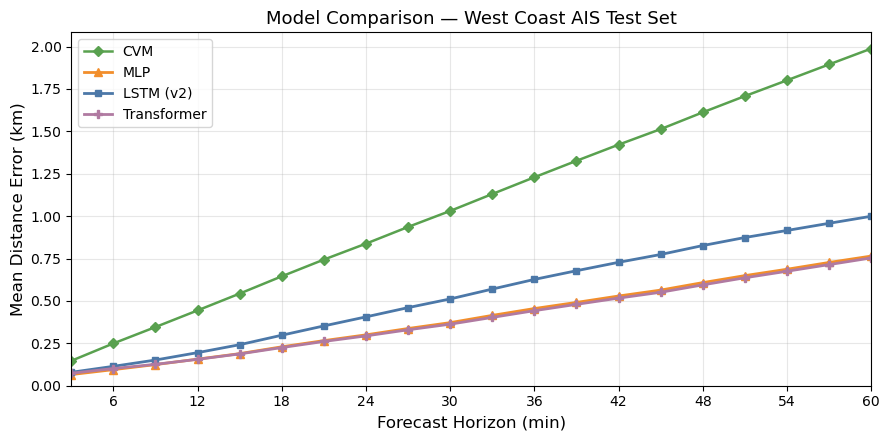

Saved: model_comparison.png


In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
styles = {
    'CVM':         dict(color='#59A14F', marker='D',  ls='-',   lw=1.8, ms=5),
    'MLP':         dict(color='#F28E2B', marker='^',  ls='-',   lw=2,   ms=6),
    'LSTM (v2)':   dict(color='#4C78A8', marker='s',  ls='-',   lw=2,   ms=5),
    'Transformer': dict(color='#B07AA1', marker='P',  ls='-',   lw=2,   ms=6),
}
for name, mde in [('CVM', cvm_mde), ('MLP', mlp_mde),
                  ('LSTM (v2)', lstm_mde), ('Transformer', txf_mde)]:
    ax.plot(HORIZONS, mde, label=name, **styles[name])
ax.set_xlabel('Forecast Horizon (min)', fontsize=12)
ax.set_ylabel('Mean Distance Error (km)', fontsize=12)
ax.set_title('Model Comparison — West Coast AIS Test Set', fontsize=13)
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
ax.set_xlim(3, 60); ax.set_ylim(0)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

In [23]:
# relative performance vs Constant Velocity Model
print('Key findings (all vs CVM mean MDE)')
print('-' * 60)
for name, mde in [('CVM', cvm_mde), ('MLP', mlp_mde),
                  ('LSTM (v2)', lstm_mde), ('Transformer', txf_mde)]:
    rel = (mde.mean() - cvm_mde.mean()) / cvm_mde.mean() * 100
    print(f'  {name:<16}  mean={mde.mean():.4f} km  '
          f'| 3 min={mde[0]:.4f}  | 60 min={mde[-1]:.4f}  '
          f'| vs CVM: {rel:+.1f}%')


Key findings (all vs CVM mean MDE)
------------------------------------------------------------
  CVM               mean=1.0775 km  | 3 min=0.1468  | 60 min=1.9881  | vs CVM: +0.0%
  MLP               mean=0.4013 km  | 3 min=0.0658  | 60 min=0.7646  | vs CVM: -62.8%
  LSTM (v2)         mean=0.5381 km  | 3 min=0.0792  | 60 min=0.9993  | vs CVM: -50.1%
  Transformer       mean=0.3942 km  | 3 min=0.0736  | 60 min=0.7536  | vs CVM: -63.4%


CVM              | slow (n=5,582,798): mean=0.0814 km | move (n=1,095,898): mean=6.1517 km
MLP              | slow (n=5,582,798): mean=0.0693 km | move (n=1,095,898): mean=2.0927 km
LSTM (v2)        | slow (n=5,582,798): mean=0.1778 km | move (n=1,095,898): mean=2.3444 km
Transformer      | slow (n=5,582,798): mean=0.0690 km | move (n=1,095,898): mean=2.0510 km


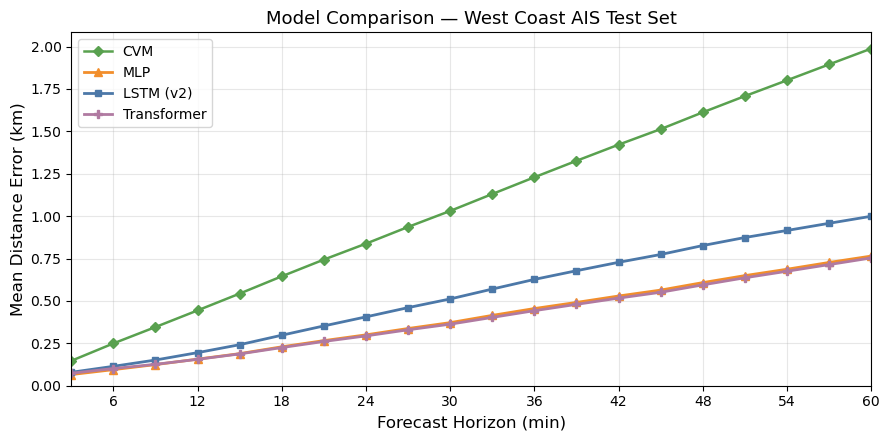

Saved: model_comparison.png


In [28]:
# SOG-stratified evaluation (slow: mean SOG < 0.5 kn, move: >= 0.5 kn)
SOG_THRESHOLD = 0.5   # knots

results_sog = {}
for name, model_obj, mtype in [
        ('CVM',          None,       'cvm'),
        ('MLP',          mlp_model,  'mlp'),
        ('LSTM (v2)',     lstm_model, 'lstm'),
        ('Transformer',  txf_model,  'transformer')]:
    slow, move, n_s, n_m = compute_mde_by_sog(
        model_obj, test_loader, mtype, sog_threshold=SOG_THRESHOLD)
    results_sog[name] = {'slow': slow, 'move': move, 'n_slow': n_s, 'n_move': n_m}
    print(
    f'{name:<16} | slow (n={n_s:>8,}): mean={slow.mean():.4f} km '
    f'| move (n={n_m:>8,}): mean={move.mean():.4f} km'
)
fig, ax = plt.subplots(figsize=(9, 4.5))
styles = {
    'CVM':         dict(color='#59A14F', marker='D',  ls='-',   lw=1.8, ms=5),
    'MLP':         dict(color='#F28E2B', marker='^',  ls='-',   lw=2,   ms=6),
    'LSTM (v2)':   dict(color='#4C78A8', marker='s',  ls='-',   lw=2,   ms=5),
    'Transformer': dict(color='#B07AA1', marker='P',  ls='-',   lw=2,   ms=6),
}
for name, mde in [('CVM', cvm_mde), ('MLP', mlp_mde),
                  ('LSTM (v2)', lstm_mde), ('Transformer', txf_mde)]:
    ax.plot(HORIZONS, mde, label=name, **styles[name])
ax.set_xlabel('Forecast Horizon (min)', fontsize=12)
ax.set_ylabel('Mean Distance Error (km)', fontsize=12)
ax.set_title('Model Comparison — West Coast AIS Test Set', fontsize=13)
ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
ax.set_xlim(3, 60); ax.set_ylim(0)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')


In [29]:
for grp, grp_key in [('Stationary (mean SOG < 0.5 kn)', 'slow'),
                     ('Underway   (mean SOG ≥ 0.5 kn)', 'move')]:
    rows = []
    for name in ['CVM', 'MLP', 'LSTM (v2)', 'Transformer']:
        mde = results_sog[name][grp_key]
        rows.append({'Model': name,
                     '3 min':    round(float(mde[0]),   4),
                     '15 min':   round(float(mde[4]),   4),
                     '30 min':   round(float(mde[9]),   4),
                     '60 min':   round(float(mde[19]),  4),
                     'Mean MDE': round(float(mde.mean()), 4)})
    df = pd.DataFrame(rows).set_index('Model')
    print(f'\n{grp}')
    print('=' * 65)
    print(df.to_string())



Stationary (mean SOG < 0.5 kn)
              3 min  15 min  30 min  60 min  Mean MDE
Model                                                
CVM          0.0129  0.0363  0.0714  0.1673    0.0814
MLP          0.0134  0.0301  0.0601  0.1418    0.0693
LSTM (v2)    0.0337  0.0860  0.1860  0.2752    0.1778
Transformer  0.0175  0.0341  0.0602  0.1374    0.0690

Underway   (mean SOG ≥ 0.5 kn)
              3 min  15 min  30 min   60 min  Mean MDE
Model                                                 
CVM          0.8292  3.1262  5.9182  11.2635    6.1517
MLP          0.3326  0.9994  1.9609   3.9371    2.0927
LSTM (v2)    0.3123  1.0254  2.1462   4.6245    2.3444
Transformer  0.3595  0.9691  1.9051   3.8926    2.0510


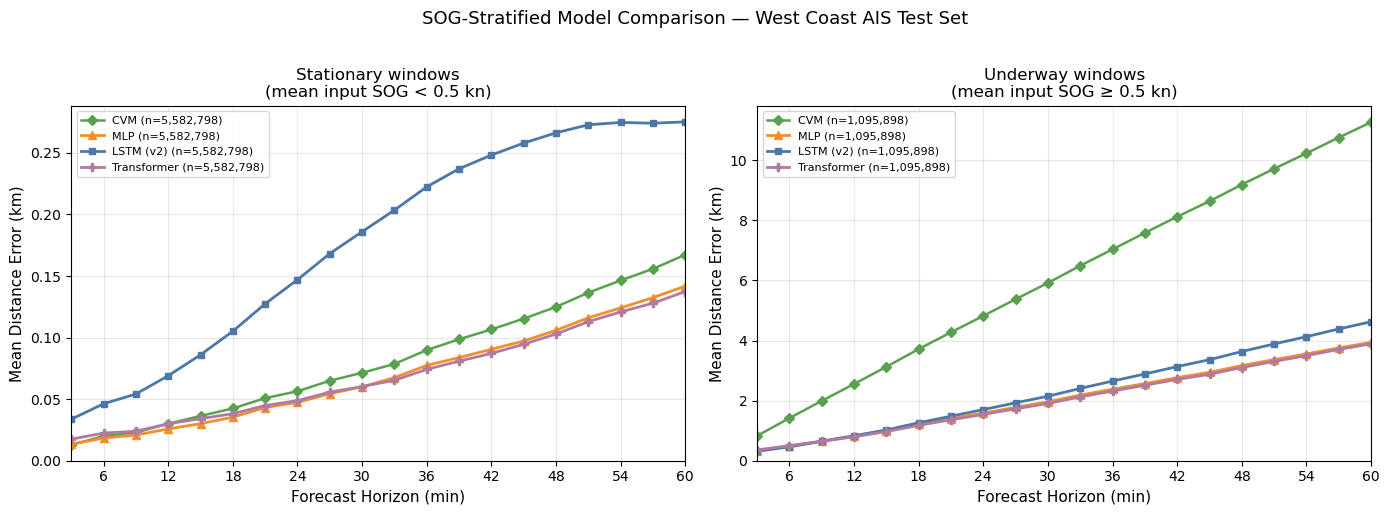

Saved: model_comparison_by_sog.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
titles = ['Stationary windows\n(mean input SOG < 0.5 kn)',
          'Underway windows\n(mean input SOG ≥ 0.5 kn)']
grp_keys = ['slow', 'move']
styles = {
    'CVM':         dict(color='#59A14F', marker='D',  ls='-',   lw=1.8, ms=5),
    'MLP':         dict(color='#F28E2B', marker='^',  ls='-',   lw=2,   ms=6),
    'LSTM (v2)':   dict(color='#4C78A8', marker='s',  ls='-',   lw=2,   ms=5),
    'Transformer': dict(color='#B07AA1', marker='P',  ls='-',   lw=2,   ms=6),
}
for ax, grp_key, title in zip(axes, grp_keys, titles):
    for name in ['CVM', 'MLP', 'LSTM (v2)', 'Transformer']:
        mde = results_sog[name][grp_key]
        n   = results_sog[name][f'n_{grp_key}']
        ax.plot(HORIZONS, mde, label=f'{name} (n={n:,})', **styles[name])
    ax.set_xlabel('Forecast Horizon (min)', fontsize=11)
    ax.set_ylabel('Mean Distance Error (km)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(6))
    ax.set_xlim(3, 60); ax.set_ylim(0)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('SOG-Stratified Model Comparison — West Coast AIS Test Set',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_by_sog.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_by_sog.png')

### Overall Interpretation

1. The constant-velocity model degrades rapidly with horizon (reaching ~2.0 km at 60 minutes), suggesting that deep-learning methods could improve on this physics model baseline. All learned models beat it substantially on underway vessels, validating the deep learning approach.

2. Both the MLP and Transformer achieve near-identical mean MDE across all horizons (~0.75 km at 60 min), and their curves are essentially indistinguishable in every subplot. The transformer likely requires longer context windows or richer features (vessel type, weather) to differentiate itself.

3. The LSTM seems to struggle the most on stationary windows, bending sharply upward while MLP/Transformer remain flat, suggesting the model continues to predict non-zero displacement even when vessels are anchored. On moving windows the LSTM performs much better relative to CVM but still does worse than MLP/Transformer.

4. The stationary subplots show that MLP and Transformer generalize cleanly to anchored vessels despite their removal from training, while the LSTM does not, a practical thing to note for any real life uses of a model covering mixed fleet.